# Add GEOID from Latitude/Longitude and Merge with Census Data

This notebook shows a minimal pipeline to enrich the LAPD crime dataset that includes **latitude/longitude** by adding the **Census Tract GEOID**, then **joining** that with **ACS/Census** attributes.

**Workflow**
1. **Load** the primary dataset (must include `lat`/`lon`).
2. **Convert** `lat`/`lon` to tract **GEOID** (via geocoding service, TIGER shapefiles, or a helper library).
3. **Load/Fetch** the desired **ACS** variables keyed by tract **GEOID**.
4. **Merge** the ACS data into the primary data on **GEOID**.
5. **Validate**: check unmatched GEOIDs, duplicates, and spot‑check a few rows.

In [26]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

In [27]:
# - Load your primary dataset that contains `lat`/`lon` columns.
# - Confirm column names and types.

# data_file = 'Crime_Data_from_2020_to_Present.csv'  # ensure this file is present in the working directory

# read data
crime_df = pd.read_csv(r"data\Crime_Data_from_2020_to_Present.csv", encoding="ISO-8859-1")

# inspect columns to know what fields we have
crime_df.columns.tolist()


['DR_NO',
 'Date Rptd',
 'DATE OCC',
 'TIME OCC',
 'AREA',
 'AREA NAME',
 'Rpt Dist No',
 'Part 1-2',
 'Crm Cd',
 'Crm Cd Desc',
 'Mocodes',
 'Vict Age',
 'Vict Sex',
 'Vict Descent',
 'Premis Cd',
 'Premis Desc',
 'Weapon Used Cd',
 'Weapon Desc',
 'Status',
 'Status Desc',
 'Crm Cd 1',
 'Crm Cd 2',
 'Crm Cd 3',
 'Crm Cd 4',
 'LOCATION',
 'Cross Street',
 'LAT',
 'LON']

In [28]:
# use Census Geocoder API to get ID from latitude/longitude
# notice here we don't need an API key for this step
import requests
import time

def get_geoid_from_census(df, x_col="x", y_col="y", sleep=0.2):
    """
    Calls the Census Geocoder API to retrieve Census Tract, County, and Block GEOIDs
    for each coordinate pair (lon, lat).
    """
    url = "https://geocoding.geo.census.gov/geocoder/geographies/coordinates"
    blockids = []
    tractids = []
    countyids = []
    county_names = []
    for _, row in df.iterrows():
        params = {
            "x": row[x_col],
            "y": row[y_col],
            "benchmark": "Public_AR_Current",  # current American Community Survey reference
            "vintage": "Current_Current",
            "format": "json"
        }

        try:
            r = requests.get(url, params=params, timeout=20)
            r.raise_for_status()
            data = r.json()
            geogs = data["result"]["geographies"]

            # Extract block, tract, county GEOIDs
            block_info = geogs.get("2020 Census Blocks", [{}])[0]
            tract_info = geogs.get("Census Tracts", [{}])[0]
            county_info = geogs.get("Counties", [{}])[0]

            blockids.append(block_info.get("GEOID"))
            tractids.append(tract_info.get("GEOID"))
            countyids.append(county_info.get("GEOID"))
            county_names.append(county_info.get("NAME"))

        except Exception as e:
            print(f"Error for {row[x_col]}, {row[y_col]}: {e}")
            blockids.append(None)
            tractids.append(None)
            countyids.append(None)
            county_names.append(None)

        time.sleep(sleep)  # be gentle with API so they don't block you!

    # add geoid and other attributes as new columns to dataframe
    df = df.copy()
    df["BLOCK_GEOID"] = blockids
    df["GEOID"] = tractids
    df["COUNTYID"] = countyids
    df["County_Name"] = county_names
    
    return(df)


In [29]:
# get the GEOID
subset_df = crime_df[:10] # using the first 10 incidents as an example. It will take time to do this for all incidents. 

geo_df = get_geoid_from_census(subset_df, "LON", "LAT")
print(geo_df)


       DR_NO               Date Rptd                DATE OCC  TIME OCC  AREA  \
0  211507896  04/11/2021 12:00:00 AM  11/07/2020 12:00:00 AM       845    15   
1  201516622  10/21/2020 12:00:00 AM  10/18/2020 12:00:00 AM      1845    15   
2  240913563  12/10/2024 12:00:00 AM  10/30/2020 12:00:00 AM      1240     9   
3  210704711  12/24/2020 12:00:00 AM  12/24/2020 12:00:00 AM      1310     7   
4  201418201  10/03/2020 12:00:00 AM  09/29/2020 12:00:00 AM      1830    14   
5  240412063  12/11/2024 12:00:00 AM  11/11/2020 12:00:00 AM      1210     4   
6  240317069  12/16/2024 12:00:00 AM  04/16/2020 12:00:00 AM      1350     3   
7  201115217  10/29/2020 12:00:00 AM  07/07/2020 12:00:00 AM      1400    11   
8  241708596  04/20/2024 12:00:00 AM  03/02/2020 12:00:00 AM      1200    17   
9  242113813  12/18/2024 12:00:00 AM  09/01/2020 12:00:00 AM       900    21   

     AREA NAME  Rpt Dist No  Part 1-2  Crm Cd  \
0  N Hollywood         1502         2     354   
1  N Hollywood       

In [30]:
# notice how now we have additional columns and one of them is the GEOID for the tract a crime happened
print("DataFrame after inplace rename:", geo_df.columns)

DataFrame after inplace rename: Index(['DR_NO', 'Date Rptd', 'DATE OCC', 'TIME OCC', 'AREA', 'AREA NAME',
       'Rpt Dist No', 'Part 1-2', 'Crm Cd', 'Crm Cd Desc', 'Mocodes',
       'Vict Age', 'Vict Sex', 'Vict Descent', 'Premis Cd', 'Premis Desc',
       'Weapon Used Cd', 'Weapon Desc', 'Status', 'Status Desc', 'Crm Cd 1',
       'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4', 'LOCATION', 'Cross Street', 'LAT',
       'LON', 'BLOCK_GEOID', 'GEOID', 'COUNTYID', 'County_Name'],
      dtype='object')


In [31]:
# get the unique tracts from your dataset to use to query the Census API for additional data
tracts = geo_df["GEOID"].dropna().unique().tolist()
print(tracts)

['06037121600', '06037123410', '06037128303', '06037270200', '06037275312', '06037201501', '06037231710', '06037187102', '06037111201', '06037138000']


In [56]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import pytidycensus as tc

In [63]:
crime_df = pd.read_csv(r"data/Crime_Data_from_2020_to_Present.csv", encoding="ISO-8859-1")
crime_df.head()

tracts = gpd.read_file(
    r"C:\Users\skothar6\Downloads\DTSC-3602-Group-12-Project\data\2020_Census_Tracts\2020_Census_Tracts.shp"
)

print(tracts.head())
print(tracts.columns)

   OBJECTID    CT20    LABEL    ShapeSTAre    ShapeSTLen  \
0      4992  101110  1011.10  1.229562e+07  15083.854287   
1      4993  101122  1011.22  2.845774e+07  31671.455844   
2      4994  101220  1012.20  7.522093e+06  12698.783810   
3      4995  101221  1012.21  3.812000e+06   9161.710543   
4      4996  101222  1012.22  3.191371e+06   9980.600461   

                                            geometry  
0  POLYGON ((6471651.068 1918306.964, 6471940.821...  
1  POLYGON ((6477840.844 1917081.399, 6477828.62 ...  
2  POLYGON ((6477611.571 1915577.225, 6477591.852...  
3  POLYGON ((6474841.984 1915634.509, 6474838.988...  
4  POLYGON ((6475267.737 1915630.02, 6475266.465 ...  
Index(['OBJECTID', 'CT20', 'LABEL', 'ShapeSTAre', 'ShapeSTLen', 'geometry'], dtype='object')


In [64]:
tracts["tract6"] = tracts["CT20"].astype(str).str.zfill(6)

# Build full GEOID
tracts["GEOID"] = "06" + "037" + tracts["tract6"]

tracts[["CT20", "tract6", "GEOID"]].head()

,CT20,tract6,GEOID
0,101110,101110,06037101110
1,101122,101122,06037101122
2,101220,101220,06037101220
3,101221,101221,06037101221
4,101222,101222,06037101222


In [65]:
tc.set_census_api_key("c33d610fd1795d8a01e54b2662fd81cd876af440")

ACS_VARS = [
    "B01003_001E",   # total population
    "B19013_001E",   # median household income
    "B25077_001E"    # median home value
]

acs_la = tc.get_acs(
    geography="tract",
    variables=ACS_VARS,
    state="CA",
    county="037",          # Los Angeles County (FIPS 037)
    year=2020,
    output="wide"
)

# Ensure ACS GEOID format matches our shapefile GEOID
acs_la["GEOID"] = acs_la["GEOID"].astype(str)

print("ACS shape:", acs_la.shape)
acs_la.head()

Census API key has been set for this session.
Getting data from the 2016-2020 5-year ACS
ACS shape: (2498, 11)


,GEOID,B01003_001E,B19013_001E,B25077_001E,state,county,tract,NAME,B01003_001_moe,B19013_001_moe,B25077_001_moe
0,06037199700,3006,38892,599600,06,037,199700,"Los Angeles County, California",493.0,9510.0,39412.0
1,06037199801,3618,41027,474300,06,037,199801,"Los Angeles County, California",667.0,7928.0,117306.0
2,06037199802,2419,42500,587800,06,037,199802,"Los Angeles County, California",318.0,15453.0,41288.0
3,06037199900,2687,37232,492700,06,037,199900,"Los Angeles County, California",391.0,8467.0,68881.0
4,06037201110,2203,65000,621500,06,037,201110,"Los Angeles County, California",295.0,17972.0,51835.0


In [66]:
merged_geo = tracts.merge(acs_la, on="GEOID", how="left")

# Check how many tracts matched
print("ACS matches:", merged_geo["B19013_001E"].notna().sum())

ACS matches: 2458


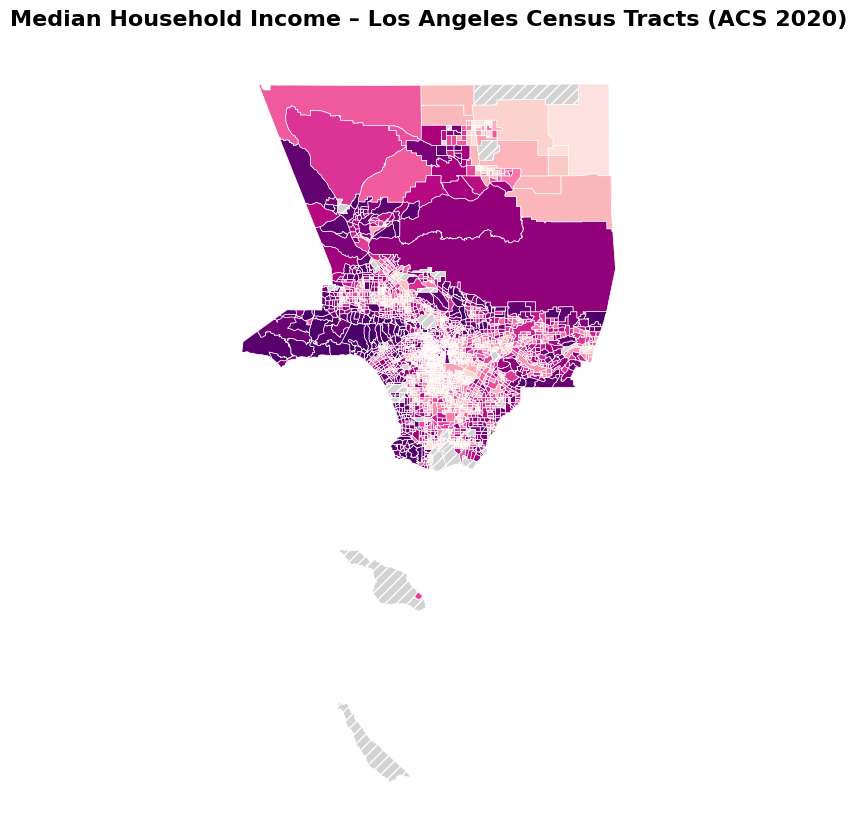

In [68]:
column_to_plot = "B19013_001E"  # ACS Median Household Income

fig, ax = plt.subplots(figsize=(12, 10))

merged_geo.plot(
    column=column_to_plot,
    ax=ax,
    cmap="RdPu",
    legend=False,
    edgecolor="white",
    linewidth=0.5,
    missing_kwds={
        "color": "lightgrey",
        "edgecolor": "white",
        "hatch": "///",
        "label": "No Data"
    }
)

ax.set_title("Median Household Income – Los Angeles Census Tracts (ACS 2020)",
             fontsize=16,
             fontweight="bold")
ax.axis("off")

plt.show()

In [35]:
# choose ACS variables that are relevant:
# - B01003_001E = total population
# - B19013_001E = median household income (inflation-adjusted)
# - B25077_001E = median home value (owner-occupied)
ACS_VARS = ["B01003_001E", "B19013_001E", "B25077_001E"]
acs_rows = []

for t in tracts:
    ca_census = tc.get_acs(
        geography= "tract",
        variables = ACS_VARS,
        state = "CA",
        year = 2020,
        tract=t,
        output = "wide")
   
# uncomment to see which columns we have
print("DataFrame after inplace rename:", ca_census.columns)

merged_data = geo_df.merge(ca_census, on="GEOID", how="left")

merged_data


Getting data from the 2016-2020 5-year ACS
Getting data from the 2016-2020 5-year ACS
Getting data from the 2016-2020 5-year ACS
Getting data from the 2016-2020 5-year ACS
Getting data from the 2016-2020 5-year ACS
Getting data from the 2016-2020 5-year ACS
Getting data from the 2016-2020 5-year ACS
DataFrame after inplace rename: Index(['GEOID', 'B01003_001E', 'B19013_001E', 'B25077_001E', 'state', 'county',
       'tract', 'NAME', 'B01003_001_moe', 'B19013_001_moe', 'B25077_001_moe'],
      dtype='object')


,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,B01003_001E,B19013_001E,B25077_001E,state,county,tract,NAME,B01003_001_moe,B19013_001_moe,B25077_001_moe
0,211507896,04/11/2021 12:00:00 AM,11/07/2020 12:00:00 AM,845,15,N Hollywood,1502,2,354,THEFT OF IDENTITY,...,2838,79048,581500,06,037,121600,"Los Angeles County, California",432.0,17660.0,26499.0
1,201516622,10/21/2020 12:00:00 AM,10/18/2020 12:00:00 AM,1845,15,N Hollywood,1521,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,3861,51094,595600,06,037,123410,"Los Angeles County, California",584.0,11308.0,64778.0
2,240913563,12/10/2024 12:00:00 AM,10/30/2020 12:00:00 AM,1240,9,Van Nuys,933,2,354,THEFT OF IDENTITY,...,4063,38880,395500,06,037,128303,"Los Angeles County, California",650.0,4776.0,69648.0
3,210704711,12/24/2020 12:00:00 AM,12/24/2020 12:00:00 AM,1310,7,Wilshire,782,1,331,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,...,3590,68651,987100,06,037,270200,"Los Angeles County, California",602.0,11054.0,104577.0
4,201418201,10/03/2020 12:00:00 AM,09/29/2020 12:00:00 AM,1830,14,Pacific,1454,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),...,2061,100667,871900,06,037,275312,"Los Angeles County, California",273.0,17720.0,26678.0
5,240412063,12/11/2024 12:00:00 AM,11/11/2020 12:00:00 AM,1210,4,Hollenbeck,429,2,354,THEFT OF IDENTITY,...,5560,69153,568800,06,037,201501,"Los Angeles County, California",636.0,6166.0,34192.0
6,240317069,12/16/2024 12:00:00 AM,04/16/2020 12:00:00 AM,1350,3,Southwest,396,2,354,THEFT OF IDENTITY,...,4135,32301,482500,06,037,231710,"Los Angeles County, California",829.0,4789.0,182289.0
7,201115217,10/29/2020 12:00:00 AM,07/07/2020 12:00:00 AM,1400,11,Northeast,1133,2,812,CRM AGNST CHLD (13 OR UNDER) (14-15 & SUSP 10 ...,...,4376,67617,779900,06,037,187102,"Los Angeles County, California",740.0,21600.0,60995.0
8,241708596,04/20/2024 12:00:00 AM,03/02/2020 12:00:00 AM,1200,17,Devonshire,1729,2,354,THEFT OF IDENTITY,...,3459,102266,674700,06,037,111201,"Los Angeles County, California",725.0,17036.0,50657.0
9,242113813,12/18/2024 12:00:00 AM,09/01/2020 12:00:00 AM,900,21,Topanga,2196,2,354,THEFT OF IDENTITY,...,4766,145968,880100,06,037,138000,"Los Angeles County, California",530.0,24300.0,43953.0



---

## Things to keep in mind when using GEOID to merge data

- **CRS sanity**: If using GeoPandas, confirm point CRS is `EPSG:4326` before spatial join.

- **GEOID format**: Tract GEOID should be a zero‑padded 11‑char string (e.g., `'06085501600'`). If needed: `df['GEOID'] = df['GEOID'].astype(str).str.zfill(11)`

- **Uniqueness**: Verify GEOID uniqueness in ACS table (one row per tract).

- **Unmatched**: Count rows with missing ACS after merge (*left‑only* keys).

- **Spot‑check**: Manually verify 3–5 merged records (GEOID ↔ expected tract/location).

### We standardized variable names and types so our model and visualizations can refer to the variables consistently.
GEOIDs were padded to 11 digits to avoid merge errors.

In [36]:
# Clean GEOID format
merged_data["GEOID"] = merged_data["GEOID"].astype(str).str.zfill(11)

# Clean income and home value columns
merged_data.rename(columns={
    "B01003_001E": "total_population",
    "B19013_001E": "median_income",
    "B25077_001E": "median_home_value"
}, inplace=True)

In [37]:
merged_data["pop_density_proxy"] = (
    merged_data["total_population"] /
    merged_data["total_population"].max()
)

In [38]:
crime_counts = merged_data.groupby("GEOID").size().rename("crime_count")
merged_data = merged_data.merge(crime_counts, on="GEOID", how="left")

merged_data["crime_per_1000"] = (
    merged_data["crime_count"] / merged_data["total_population"] * 1000
)

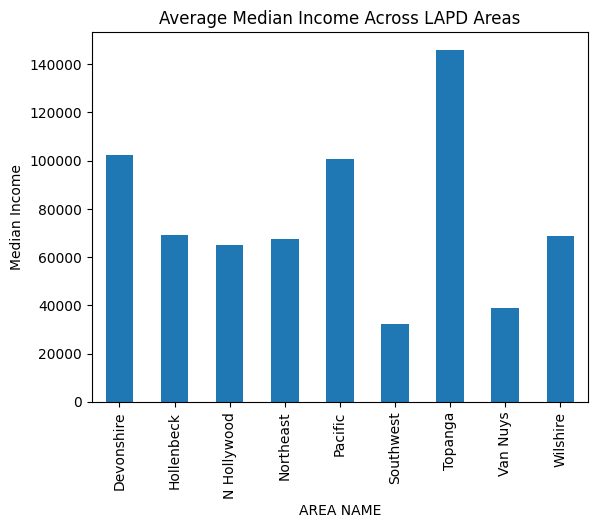

In [39]:
merged_data.groupby("AREA NAME")["median_income"].mean().plot(kind="bar")
plt.title("Average Median Income Across LAPD Areas")
plt.ylabel("Median Income")
plt.show()

In [40]:
merged_data[["GEOID", "crime_per_1000"]].drop_duplicates().sort_values("crime_per_1000", ascending=False).head(10)

,GEOID,crime_per_1000
4,06037275312,0.485201
0,06037121600,0.352361
8,06037111201,0.289101
3,06037270200,0.278552
1,06037123410,0.259000
2,06037128303,0.246124
6,06037231710,0.241838
7,06037187102,0.228519
9,06037138000,0.209820
5,06037201501,0.179856


## Step 5: Create New Contextual Features

Now that we have merged the crime data with ACS census data at the census‐tract level (via `GEOID`), we can create new contextual features that help describe the social and economic environment around each tract.

Below, we engineered two new features:

1. **`income_zscore`** – a standardized version of median household income, showing how rich or poor each tract is relative to the citywide average.
2. **`residents_per_crime`** – the number of residents per recorded crime in a tract, which is another way to express crime exposure relative to population size.

In [41]:
import numpy as np
# --- New contextual feature 1: standardized income (z-score) ---
# This measures how far a tract's median income is from the overall mean, in standard deviation units.
income_mean = merged_data["median_income"].mean()
income_std = merged_data["median_income"].std()

merged_data["income_zscore"] = (merged_data["median_income"] - income_mean) / income_std

# --- New contextual feature 2: residents per crime ---
# This summarizes how many residents there are for each recorded crime in the tract.
# Higher values = fewer crimes per resident; lower values = more crimes per resident.

merged_data["residents_per_crime"] = merged_data["total_population"] / merged_data["crime_count"]

# Replace infinite values (e.g., where crime_count is 0) with NaN
merged_data["residents_per_crime"].replace([np.inf, -np.inf], np.nan, inplace=True)

# Quick sanity check
merged_data[["GEOID", "median_income", "income_zscore", "total_population","crime_count", "residents_per_crime"]].head()


C:\Users\skothar6\AppData\Local\Temp\ipykernel_3768\554268883.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  merged_data["residents_per_crime"].replace([np.inf, -np.inf], np.nan, inplace=True)


,GEOID,median_income,income_zscore,total_population,crime_count,residents_per_crime
0,06037121600,79048,0.103071,2838,1,2838.0
1,06037123410,51094,-0.72404,3861,1,3861.0
2,06037128303,38880,-1.085431,4063,1,4063.0
3,06037270200,68651,-0.204558,3590,1,3590.0
4,06037275312,100667,0.742739,2061,1,2061.0


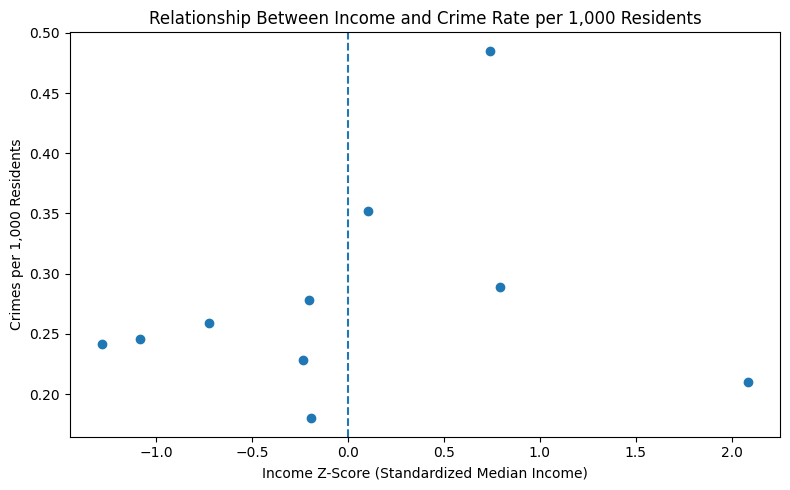

In [42]:
plt.figure(figsize=(8, 5))

# Drop rows with missing values in either variable to keep the plot clean
scatter_df = merged_data[["income_zscore", "crime_per_1000"]].dropna()

plt.scatter(scatter_df["income_zscore"], scatter_df["crime_per_1000"])
plt.axvline(0, linestyle="--")  # line at mean income
plt.xlabel("Income Z-Score (Standardized Median Income)")
plt.ylabel("Crimes per 1,000 Residents")
plt.title("Relationship Between Income and Crime Rate per 1,000 Residents")

plt.tight_layout()
plt.show()


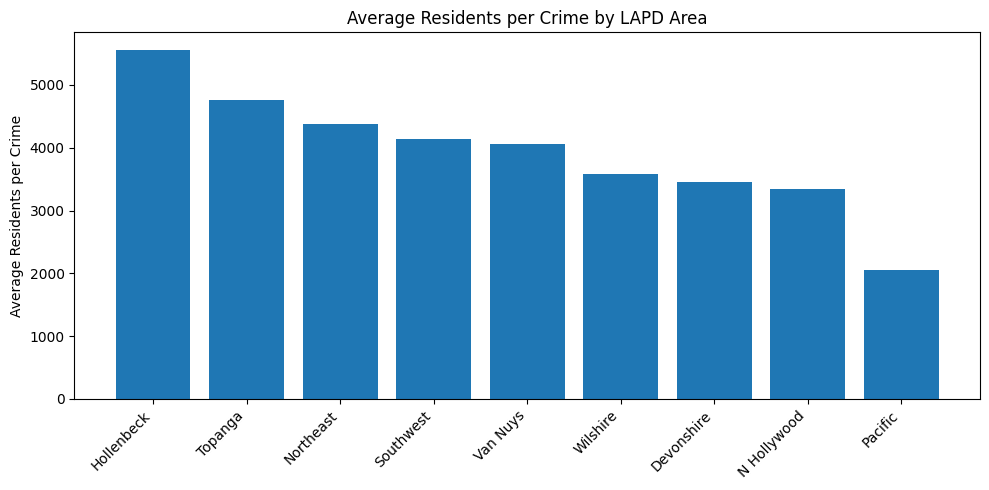

,AREA NAME,avg_residents_per_crime,avg_crime_per_1000,avg_median_income
1,Hollenbeck,5560.0,0.179856,69153.0
6,Topanga,4766.0,0.209820,145968.0
3,Northeast,4376.0,0.228519,67617.0
5,Southwest,4135.0,0.241838,32301.0
7,Van Nuys,4063.0,0.246124,38880.0
8,Wilshire,3590.0,0.278552,68651.0
0,Devonshire,3459.0,0.289101,102266.0
2,N Hollywood,3349.5,0.305681,65071.0
4,Pacific,2061.0,0.485201,100667.0


In [43]:
# Bar chart: average residents per crime by LAPD AREA NAME

area_summary = (
    merged_data
    .groupby("AREA NAME")
    .agg(
        avg_residents_per_crime=("residents_per_crime", "mean"),
        avg_crime_per_1000=("crime_per_1000", "mean"),
        avg_median_income=("median_income", "mean")
    )
    .reset_index()
)

# Sort by residents_per_crime for a cleaner bar chart
area_summary_sorted = area_summary.sort_values("avg_residents_per_crime", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(area_summary_sorted["AREA NAME"], area_summary_sorted["avg_residents_per_crime"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Average Residents per Crime")
plt.title("Average Residents per Crime by LAPD Area")

plt.tight_layout()
plt.show()

area_summary_sorted.head(10)
